In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("health_dataset_50_records.csv")

print(df.head())  # check data

   ID  Age  Gender  Height_cm  Weight_kg    BMI  Daily_Steps  Sleep_Hours  \
0   1   29    Male        161         59  22.76         9896          5.2   
1   2   19    Male        159         81  32.04         6925          4.2   
2   3   25  Female        156         75  30.82         9362          5.7   
3   4   26  Female        157         77  31.24         7688          5.5   
4   5   29    Male        179         54  16.85        11999          5.5   

   Water_Intake_L  Screen_Time_hr  Exercise_min_per_day  Calories_Intake  
0             2.9             4.0                    34             2539  
1             2.0             3.2                    18             1761  
2             3.3             8.6                    90             2469  
3             3.3             6.4                    84             2893  
4             2.7             9.3                    41             2547  


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [4]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    else:
        return 2

df['BMI_Category'] = df['BMI'].apply(bmi_category)

print(df[['BMI', 'BMI_Category']].head())

     BMI  BMI_Category
0  22.76             1
1  32.04             2
2  30.82             2
3  31.24             2
4  16.85             0


In [6]:
X = df.drop(['ID', 'BMI_Category'], axis=1)
y = df['BMI_Category']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Logistic Regression: 0.9


In [10]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("SVM:", accuracy_score(y_test, y_pred_svm))

SVM: 0.6


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Decision Tree: 1.0


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Random Forest: 1.0


In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN:", accuracy_score(y_test, y_pred_knn))

KNN: 0.6


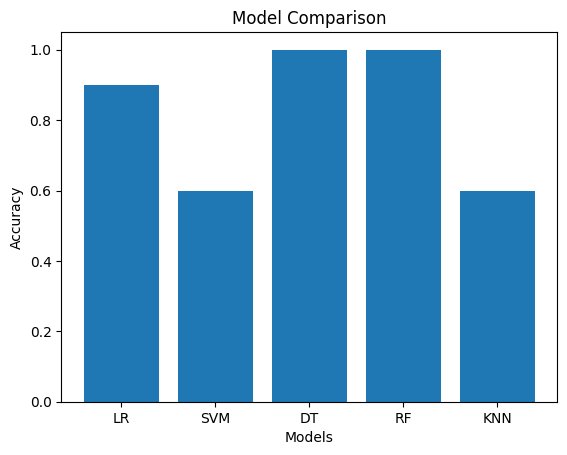

In [14]:
import matplotlib.pyplot as plt

models = ['LR', 'SVM', 'DT', 'RF', 'KNN']
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_knn)
]

plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load CSV
df = pd.read_csv("health_dataset_50_records.csv")

# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Target
def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    else:
        return 2

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# Features
X = df.drop(['ID', 'BMI_Category'], axis=1)
y = df['BMI_Category']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression: 0.9


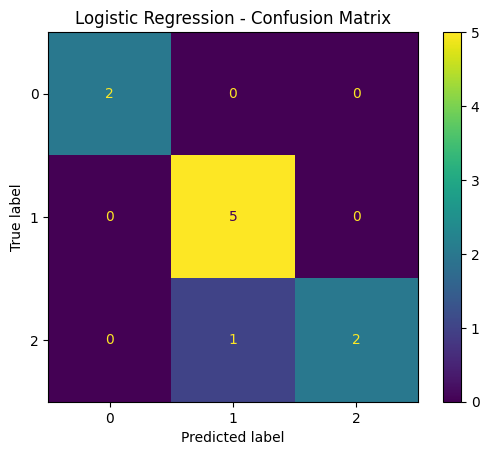

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Accuracy
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

SVM: 0.6


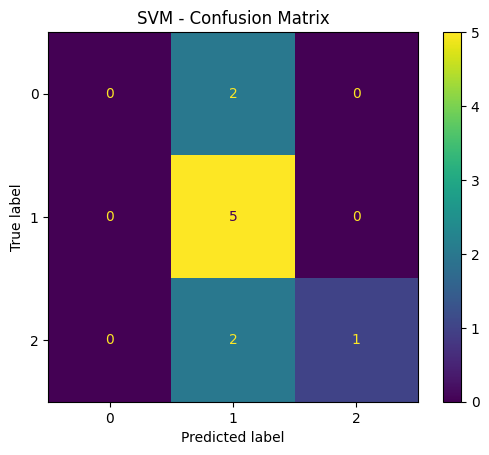

In [17]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM:", accuracy_score(y_test, y_pred_svm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM - Confusion Matrix")
plt.show()

Decision Tree: 1.0


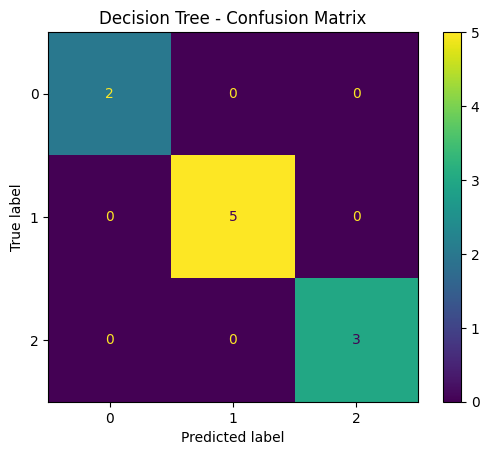

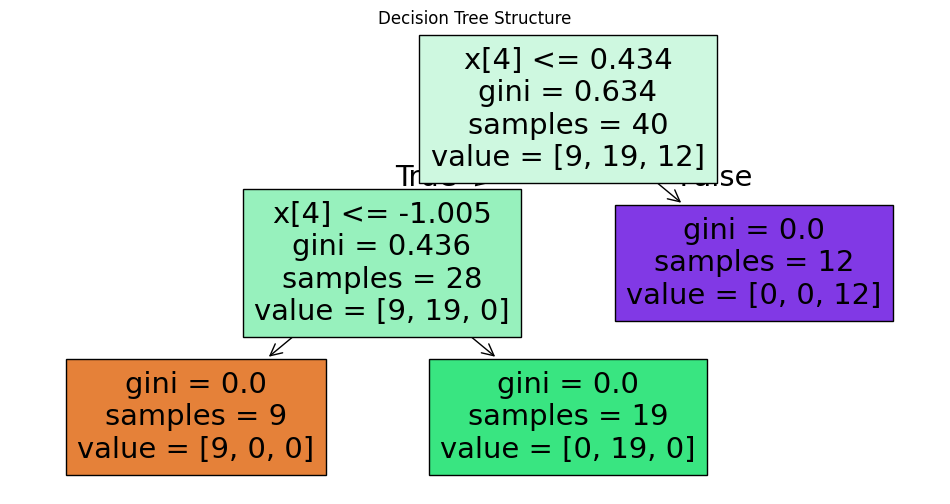

In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm).plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# Tree Graph
plt.figure(figsize=(12,6))
plot_tree(dt, filled=True)
plt.title("Decision Tree Structure")
plt.show()

Random Forest: 1.0


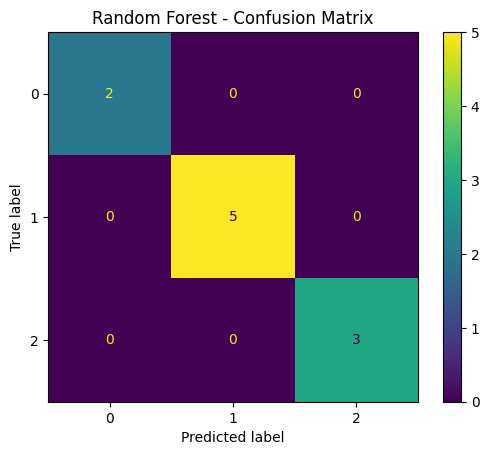

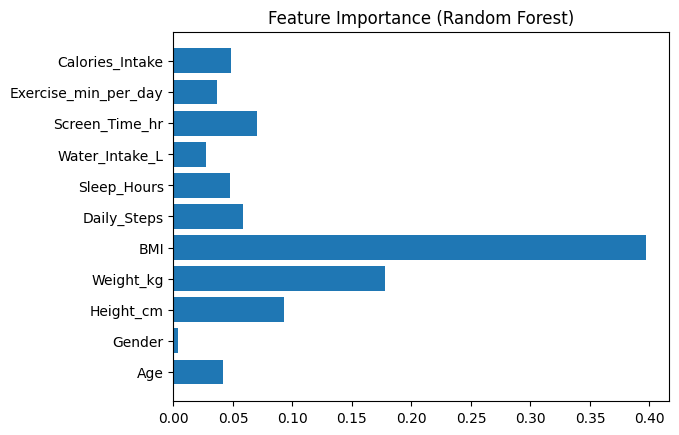

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Feature Importance
importances = rf.feature_importances_
features = df.drop(['ID','BMI_Category'], axis=1).columns

plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

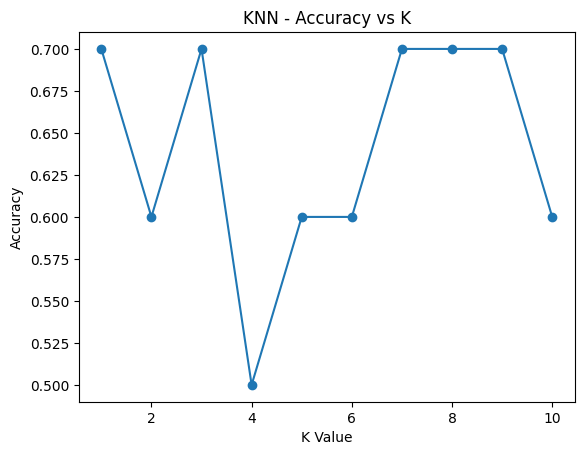

In [20]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot K vs Accuracy
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN - Accuracy vs K")
plt.show()

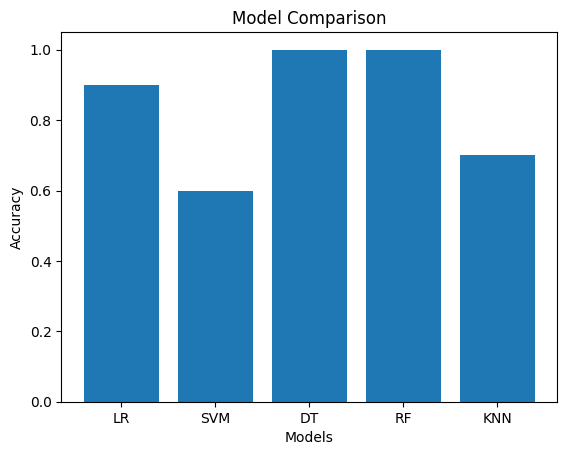

In [21]:
models = ['LR', 'SVM', 'DT', 'RF', 'KNN']

scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    max(accuracies)  # best KNN
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

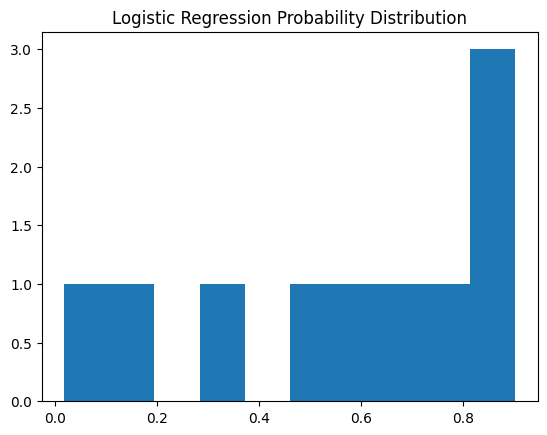

In [22]:
probs = lr.predict_proba(X_test)

plt.hist(probs[:,1])
plt.title("Logistic Regression Probability Distribution")
plt.show()

In [3]:
import pandas as pd

# LOAD DATASET (VERY IMPORTANT)
df = pd.read_csv("health_dataset_50_records.csv")

# Check if loaded
print(df.head())

   ID  Age  Gender  Height_cm  Weight_kg    BMI  Daily_Steps  Sleep_Hours  \
0   1   29    Male        161         59  22.76         9896          5.2   
1   2   19    Male        159         81  32.04         6925          4.2   
2   3   25  Female        156         75  30.82         9362          5.7   
3   4   26  Female        157         77  31.24         7688          5.5   
4   5   29    Male        179         54  16.85        11999          5.5   

   Water_Intake_L  Screen_Time_hr  Exercise_min_per_day  Calories_Intake  
0             2.9             4.0                    34             2539  
1             2.0             3.2                    18             1761  
2             3.3             8.6                    90             2469  
3             3.3             6.4                    84             2893  
4             2.7             9.3                    41             2547  


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    else:
        return 2

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# NOW this will work ✅
X = df.drop(['ID', 'BMI_Category'], axis=1)
y = df['BMI_Category']

In [5]:
# RUN THIS FIRST ALWAYS
print("Dataset loaded:", df.shape)

Dataset loaded: (50, 13)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [5]:
df = pd.read_csv("health_dataset_50_records.csv")
print(df.head())

   ID  Age  Gender  Height_cm  Weight_kg    BMI  Daily_Steps  Sleep_Hours  \
0   1   29    Male        161         59  22.76         9896          5.2   
1   2   19    Male        159         81  32.04         6925          4.2   
2   3   25  Female        156         75  30.82         9362          5.7   
3   4   26  Female        157         77  31.24         7688          5.5   
4   5   29    Male        179         54  16.85        11999          5.5   

   Water_Intake_L  Screen_Time_hr  Exercise_min_per_day  Calories_Intake  
0             2.9             4.0                    34             2539  
1             2.0             3.2                    18             1761  
2             3.3             8.6                    90             2469  
3             3.3             6.4                    84             2893  
4             2.7             9.3                    41             2547  


In [6]:
# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Create BMI Category target
def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    else:
        return 2

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# Features and target
X = df.drop(['ID', 'BMI_Category'], axis=1)
y = df['BMI_Category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Optional: scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Decision Tree Accuracy (Entropy): 1.0


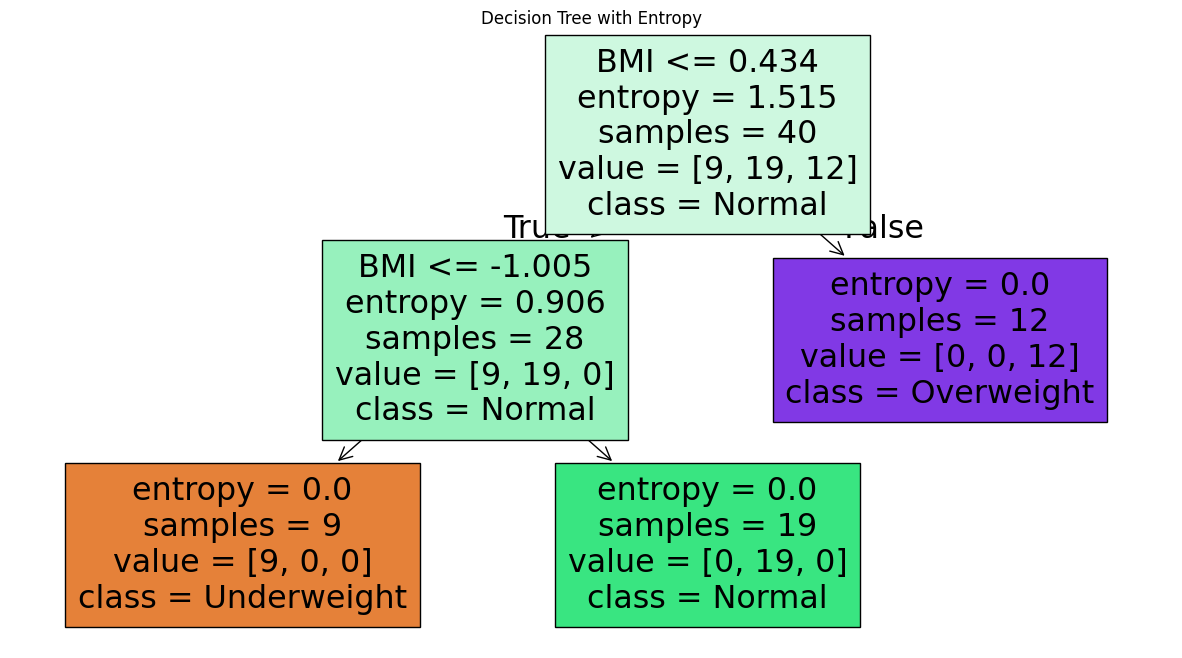

In [7]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4)
dt_entropy.fit(X_train, y_train)
y_pred_dt_entropy = dt_entropy.predict(X_test)

print("Decision Tree Accuracy (Entropy):", accuracy_score(y_test, y_pred_dt_entropy))

# Plot tree with entropy
plt.figure(figsize=(15,8))
plot_tree(
    dt_entropy, 
    filled=True, 
    feature_names=X.columns, 
    class_names=["Underweight","Normal","Overweight"], 
    impurity=True  # show entropy in each node
)
plt.title("Decision Tree with Entropy")
plt.show()

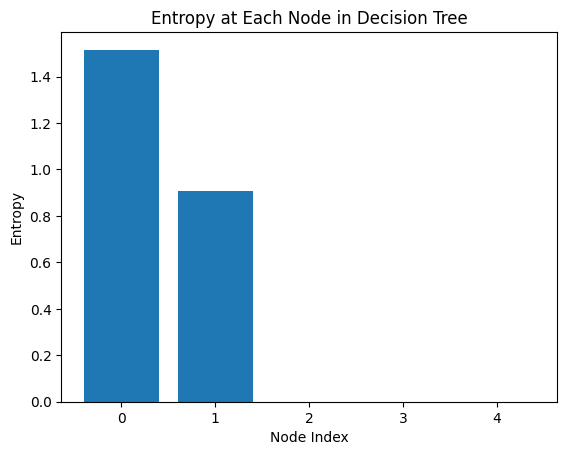

In [8]:
# Compute entropy at each node
def compute_entropy(y_node):
    classes, counts = np.unique(y_node, return_counts=True)
    probs = counts / counts.sum()
    entropy = -np.sum(probs * np.log2(probs + 1e-9))
    return entropy

entropy_values = []
for i in range(dt_entropy.tree_.node_count):
    samples_idx = dt_entropy.tree_.value[i][0]
    total = samples_idx.sum()
    if total > 0:
        probs = samples_idx / total
        entropy_node = -np.sum(probs * np.log2(probs + 1e-9))
        entropy_values.append(entropy_node)

plt.bar(range(len(entropy_values)), entropy_values)
plt.xlabel("Node Index")
plt.ylabel("Entropy")
plt.title("Entropy at Each Node in Decision Tree")
plt.show()

In [9]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# List of depths to test
depths = range(1, 11)

train_acc = []
test_acc = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, criterion='entropy', random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc.append(dt.score(X_train, y_train))  # accuracy on training data
    test_acc.append(dt.score(X_test, y_test))     # accuracy on test data

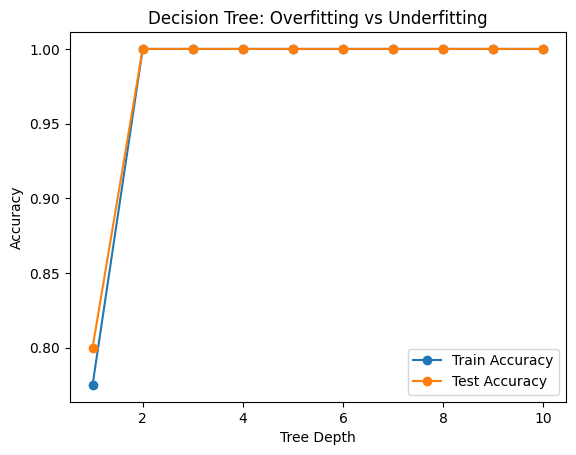

In [10]:
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Overfitting vs Underfitting')
plt.legend()
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [1, 5, 10, 20, 50, 100, 200]

train_acc_rf = []
test_acc_rf = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, max_depth=None, random_state=42)
    rf.fit(X_train, y_train)
    
    train_acc_rf.append(rf.score(X_train, y_train))
    test_acc_rf.append(rf.score(X_test, y_test))

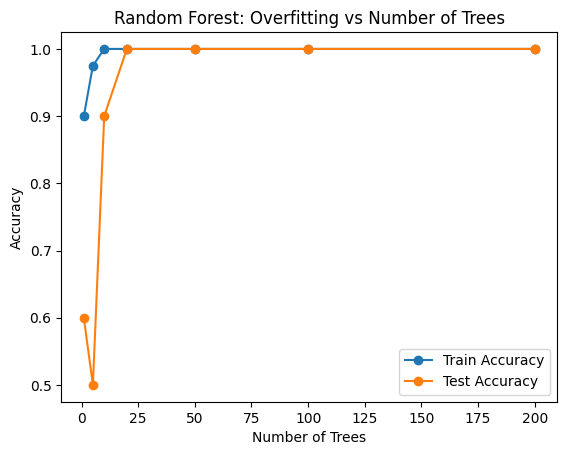

In [12]:
plt.plot(n_estimators_list, train_acc_rf, marker='o', label='Train Accuracy')
plt.plot(n_estimators_list, test_acc_rf, marker='o', label='Test Accuracy')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest: Overfitting vs Number of Trees')
plt.legend()
plt.show()

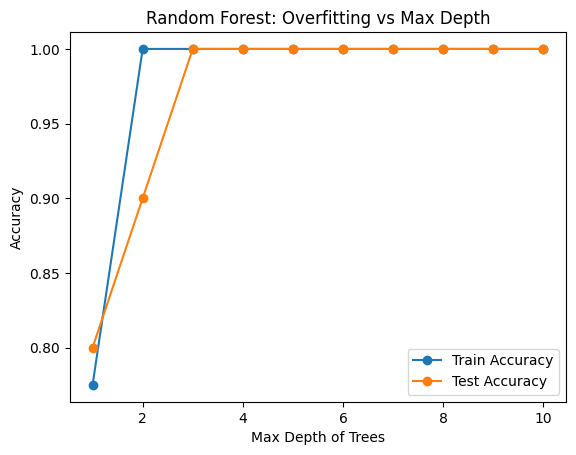

In [13]:
depths = range(1, 11)
train_acc_rf_depth = []
test_acc_rf_depth = []

for d in depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    
    train_acc_rf_depth.append(rf.score(X_train, y_train))
    test_acc_rf_depth.append(rf.score(X_test, y_test))

plt.plot(depths, train_acc_rf_depth, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc_rf_depth, marker='o', label='Test Accuracy')
plt.xlabel('Max Depth of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest: Overfitting vs Max Depth')
plt.legend()
plt.show()